# 21: What Does It Cost to Stay?

Chapter 21 introduces scarce computation: not every frontier opportunity receives an attachment evaluation.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


## Mechanism: finite evaluation slots


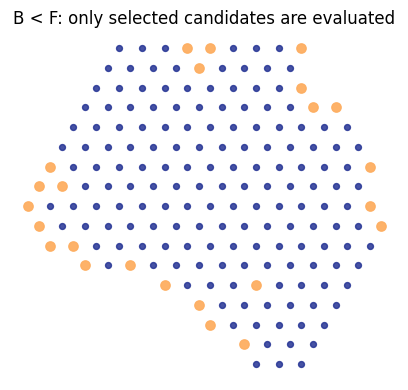

{'label': 'finite computational opportunity',
 'source': 'quick recomputed',
 'observed': {'frontier_opportunities': 32,
  'evaluation_slots': 24,
  'unevaluated_sites': 8}}

In [2]:
state = run_crystal([0.2] * 12, seed=21, max_radius=8)
F = sorted(frontier(state.occupied, 8))
B = 24
ranked = sorted(F, key=lambda c: (-sum(nb in state.occupied for nb in neighbors(c)), c))
selected = set(ranked[:B])
unevaluated = set(F) - selected
assert len(selected) == min(B, len(F))
fig, ax = plt.subplots(figsize=(5, 4))
plot_cells(ax, state.occupied, selected=selected, title="B < F: only selected candidates are evaluated")
fig.tight_layout(); fig.savefig(FIG_DIR / "ch21-budgeted-frontier-quick.png", bbox_inches="tight"); plt.show()
audit("finite computational opportunity", {"frontier_opportunities": len(F), "evaluation_slots": B, "unevaluated_sites": len(unevaluated)}, source="quick recomputed")


## V1 allocation policies: geometry-only scheduling


In [3]:
v1 = load_json("research/digital-life/ch21-finite-update-budget-v1/stage-03-policy-tradeoff.json")
verdict1 = load_json("research/digital-life/ch21-finite-update-budget-v1/stage-04-verdict.json")
summary = v1["policy_summary"]
audit("V1 fixed B=256 policy tradeoff", {
    p: {
        "late_population": summary[p]["mean_late_population"],
        "reoccupation_per_loss": summary[p]["mean_reoccupation_per_loss"],
        "first_per_1000_evals": summary[p]["mean_first_occupations_per_1000_evals"],
    } for p in ["high_support", "neutral", "low_support"]
} | {
    "first_advantage": verdict1["first_occupation_advantage_per_1000_evals"],
    "first_required": verdict1["first_occupation_sei"],
    "status": verdict1["status"],
}, source="canonical research artifact")


{'label': 'V1 fixed B=256 policy tradeoff',
 'source': 'canonical research artifact',
 'observed': {'high_support': {'late_population': 1923.1649305555554,
   'reoccupation_per_loss': 0.9587803634787203,
   'first_per_1000_evals': 187.5623346430792},
  'neutral': {'late_population': 1722.7569444444443,
   'reoccupation_per_loss': 0.8439579238175184,
   'first_per_1000_evals': 212.15684919727119},
  'low_support': {'late_population': 1130.779513888889,
   'reoccupation_per_loss': 0.533529684606526,
   'first_per_1000_evals': 249.14525447081232},
  'first_advantage': 61.582919827733086,
  'first_required': 100.0,
  'status': 'FAILED'}}

## V2 and V3 artifact audit


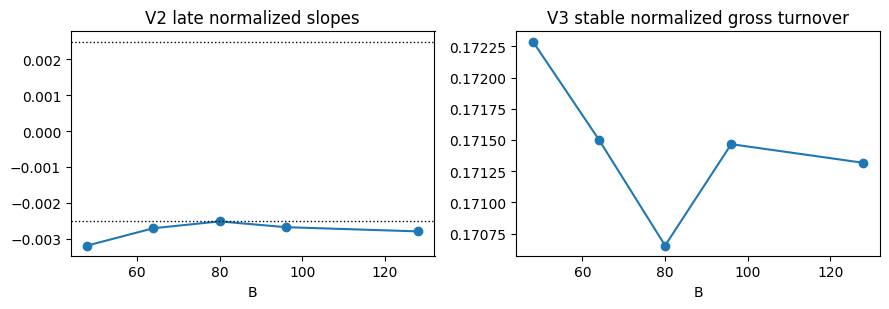

{'label': 'V2/V3',
 'source': 'canonical research artifact',
 'observed': {'v2_status': 'FAILED',
  'v2_qualifying_budgets': [],
  'v2_slopes': {'48': -0.003191772991959401,
   '64': -0.002708656932132373,
   '80': -0.0025187540145995536,
   '96': -0.0026797121474159704,
   '128': -0.0027976040167390337},
  'v3_status': 'FAILED',
  'gross_turnover_between_budget_cv': 0.0030355916081414203,
  'max_abs_gross_turnover_slope': 0.00024331874779793278,
  'B48_first_fraction_cv': 0.11799456229935522}}

In [4]:
v2fam = load_json("research/digital-life/ch21-finite-update-budget-v2/stage-02-candidate-family.json")
v2 = load_json("research/digital-life/ch21-finite-update-budget-v2/stage-04-verdict.json")
v3inv = load_json("research/digital-life/ch21-finite-update-budget-v3/stage-02-process-invariance.json")
v3 = load_json("research/digital-life/ch21-finite-update-budget-v3/stage-03-verdict.json")
budgets = [48,64,80,96,128]
slopes = [v2fam["by_budget"][str(b)]["late_normalized_population_slope"]["mean"] for b in budgets]
gross = [v3inv["mean_gross_turnover_fraction_by_budget"][str(b)] for b in budgets]
first_cv_48 = v3inv["start_size_cv_by_budget"]["48"]["first_fraction"]["cv"]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(budgets, slopes, marker="o"); ax[0].axhline(-0.0025, color="black", lw=1, ls=":"); ax[0].axhline(0.0025, color="black", lw=1, ls=":")
ax[0].set(title="V2 late normalized slopes", xlabel="B")
ax[1].plot(budgets, gross, marker="o"); ax[1].set(title="V3 stable normalized gross turnover", xlabel="B")
fig.tight_layout(); fig.savefig(FIG_DIR / "ch21-v2-v3-artifact-audit.png", bbox_inches="tight"); plt.show()
audit("V2/V3", {
    "v2_status": v2["status"],
    "v2_qualifying_budgets": v2["qualifying_budgets"],
    "v2_slopes": dict(zip(map(str,budgets), slopes)),
    "v3_status": v3["status"],
    "gross_turnover_between_budget_cv": v3inv["gross_turnover_fraction_between_budget_cv"],
    "max_abs_gross_turnover_slope": max(abs(x) for x in v3inv["max_abs_gross_turnover_fraction_slope_by_budget"].values()),
    "B48_first_fraction_cv": first_cv_48,
}, source="canonical research artifact")


## Bounded claim

Staying is not growing. Stable process traffic is not stable body size. V1, V2, and the full V3 composite claim remain failed, while loss, attachment, reoccupation, and gross turnover show striking stable normalized behavior.

## Provenance

Current local book chapter: `content/books/digital-life/21-what-does-it-cost-to-stay/index.md` (local working tree authority)

Research scripts: `ch21_digital_crystal_finite_update_budget_v1.py`, `v2.py`, `v3.py`

Canonical artifacts: `research/digital-life/ch21-finite-update-budget-v1/`, `v2/`, `v3/`

Notebook figures: `ch21-budgeted-frontier-quick.png`, `ch21-v2-v3-artifact-audit.png`

Execution mode: quick-recomputed + canonical-artifact-audit

## Claim Ledger

ASSERTION: unevaluated frontier sites receive no attachment draw under finite B.

FAILED: V1 full allocation tradeoff; V2 stationary population search; V3 full composite invariance.

SUPPORTED: stable normalized loss/attachment/reoccupation/gross-turnover traffic.

UNTESTED: energy, metabolism, homeostasis.
